# Week 2 Lab — Linear Regression & Classification
*Companion notebook to the Week 2 slides (ISLP Ch. 3–4).*

This lab follows the deck's storyline with the **same datasets, same numbers,
same figures** — every headline number on the slides is recomputed here by you.

**How this fits with the official ISLP labs (homework #2):**
- Official **Ch. 3 lab** (`Boston`, `Carseats`; interactions, polynomials, qualitative predictors):
  [Ch03-linreg-lab.ipynb](https://github.com/intro-stat-learning/ISLP_labs/blob/main/Ch03-linreg-lab.ipynb)
- Official **Ch. 4 lab** (`Smarket`; LDA, QDA, naive Bayes, KNN as optional extras):
  [Ch04-classification-lab.ipynb](https://github.com/intro-stat-learning/ISLP_labs/blob/main/Ch04-classification-lab.ipynb)

This notebook does **not** duplicate those — it covers what they don't:
the deck's `Advertising` / `Auto` / `Default` story, the accuracy trap,
the threshold decision (homework #3), and the sign-flip.

> Note: the official labs use ISLP's `ModelSpec` + `summarize` idiom.
> Here we use the `statsmodels` formula API (`smf.ols('y ~ x')`), matching the
> code shown on the slides. Both fit the same models.

### Setup — run this cell first
Installs anything missing (notably `ISLP`, which is not preinstalled on
Colab/Anaconda). On a machine that already has everything, it does nothing.

In [1]:
import importlib.util, subprocess, sys
for pkg in ["ISLP", "statsmodels", "sklearn", "pandas", "matplotlib"]:
    if importlib.util.find_spec(pkg) is None:
        name = "scikit-learn" if pkg == "sklearn" else pkg
        print(f"installing {name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", name])
print("environment ready")

environment ready


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from IPython.display import display

# deck palette
NAVY, AMBER, ALARM, BLUE, ORANGE, GRAY = \
    "#1b3a5c", "#e0a33e", "#c0392b", "#5aa9d6", "#d2691e", "#8a97a5"

# Korean plot labels need a CJK font; harmless no-op otherwise
from matplotlib import font_manager
_names = {f.name for f in font_manager.fontManager.ttflist}
_ko = next((f for f in ["Noto Sans CJK KR", "Noto Sans KR", "Malgun Gothic",
                        "Apple SD Gothic Neo", "NanumGothic"] if f in _names), None)
if _ko:
    plt.rcParams["font.family"] = _ko
    plt.rcParams["axes.unicode_minus"] = False

from ISLP import load_data
# Auto / Default / Smarket ship inside the ISLP package -> nothing to download.
# Advertising is not bundled with ISLP, so we carry it as plain Python data
# inside this notebook (see Part A) -- the notebook is fully self-contained.
Auto    = load_data("Auto")
Default = load_data("Default")
Smarket = load_data("Smarket")
print(f"Auto {Auto.shape} | Default {Default.shape} | Smarket {Smarket.shape}")

Auto (392, 8) | Default (10000, 4) | Smarket (1250, 9)


## Part A — Chapter 3: predict a number (`Advertising`, `Auto`)

### A1. The simplest useful model *(slides 5–7)*
$Y \approx \beta_0 + \beta_1 X$ — fit `sales ~ TV` by least squares and read
the two coefficients the way the deck did.

### A0. Data does not always arrive as a file
Real projects hand you data as Python objects — API responses, query results,
scraped records. The full `Advertising` data (200 markets) is embedded below as
an ordinary **dict of lists**: one key per column, one list of 200 values each.
Long cell on purpose — this *is* the dataset.

In [3]:
ADVERTISING = {
    "TV": [
        230.1, 44.5, 17.2, 151.5, 180.8, 8.7, 57.5, 120.2, 8.6, 199.8,
        66.1, 214.7, 23.8, 97.5, 204.1, 195.4, 67.8, 281.4, 69.2, 147.3,
        218.4, 237.4, 13.2, 228.3, 62.3, 262.9, 142.9, 240.1, 248.8,
        70.6, 292.9, 112.9, 97.2, 265.6, 95.7, 290.7, 266.9, 74.7, 43.1,
        228, 202.5, 177, 293.6, 206.9, 25.1, 175.1, 89.7, 239.9, 227.2,
        66.9, 199.8, 100.4, 216.4, 182.6, 262.7, 198.9, 7.3, 136.2,
        210.8, 210.7, 53.5, 261.3, 239.3, 102.7, 131.1, 69, 31.5, 139.3,
        237.4, 216.8, 199.1, 109.8, 26.8, 129.4, 213.4, 16.9, 27.5,
        120.5, 5.4, 116, 76.4, 239.8, 75.3, 68.4, 213.5, 193.2, 76.3,
        110.7, 88.3, 109.8, 134.3, 28.6, 217.7, 250.9, 107.4, 163.3,
        197.6, 184.9, 289.7, 135.2, 222.4, 296.4, 280.2, 187.9, 238.2,
        137.9, 25, 90.4, 13.1, 255.4, 225.8, 241.7, 175.7, 209.6, 78.2,
        75.1, 139.2, 76.4, 125.7, 19.4, 141.3, 18.8, 224, 123.1, 229.5,
        87.2, 7.8, 80.2, 220.3, 59.6, 0.7, 265.2, 8.4, 219.8, 36.9, 48.3,
        25.6, 273.7, 43, 184.9, 73.4, 193.7, 220.5, 104.6, 96.2, 140.3,
        240.1, 243.2, 38, 44.7, 280.7, 121, 197.6, 171.3, 187.8, 4.1,
        93.9, 149.8, 11.7, 131.7, 172.5, 85.7, 188.4, 163.5, 117.2,
        234.5, 17.9, 206.8, 215.4, 284.3, 50, 164.5, 19.6, 168.4, 222.4,
        276.9, 248.4, 170.2, 276.7, 165.6, 156.6, 218.5, 56.2, 287.6,
        253.8, 205, 139.5, 191.1, 286, 18.7, 39.5, 75.5, 17.2, 166.8,
        149.7, 38.2, 94.2, 177, 283.6, 232.1
    ],
    "Radio": [
        37.8, 39.3, 45.9, 41.3, 10.8, 48.9, 32.8, 19.6, 2.1, 2.6, 5.8,
        24, 35.1, 7.6, 32.9, 47.7, 36.6, 39.6, 20.5, 23.9, 27.7, 5.1,
        15.9, 16.9, 12.6, 3.5, 29.3, 16.7, 27.1, 16, 28.3, 17.4, 1.5, 20,
        1.4, 4.1, 43.8, 49.4, 26.7, 37.7, 22.3, 33.4, 27.7, 8.4, 25.7,
        22.5, 9.9, 41.5, 15.8, 11.7, 3.1, 9.6, 41.7, 46.2, 28.8, 49.4,
        28.1, 19.2, 49.6, 29.5, 2, 42.7, 15.5, 29.6, 42.8, 9.3, 24.6,
        14.5, 27.5, 43.9, 30.6, 14.3, 33, 5.7, 24.6, 43.7, 1.6, 28.5,
        29.9, 7.7, 26.7, 4.1, 20.3, 44.5, 43, 18.4, 27.5, 40.6, 25.5,
        47.8, 4.9, 1.5, 33.5, 36.5, 14, 31.6, 3.5, 21, 42.3, 41.7, 4.3,
        36.3, 10.1, 17.2, 34.3, 46.4, 11, 0.3, 0.4, 26.9, 8.2, 38, 15.4,
        20.6, 46.8, 35, 14.3, 0.8, 36.9, 16, 26.8, 21.7, 2.4, 34.6, 32.3,
        11.8, 38.9, 0, 49, 12, 39.6, 2.9, 27.2, 33.5, 38.6, 47, 39, 28.9,
        25.9, 43.9, 17, 35.4, 33.2, 5.7, 14.8, 1.9, 7.3, 49, 40.3, 25.8,
        13.9, 8.4, 23.3, 39.7, 21.1, 11.6, 43.5, 1.3, 36.9, 18.4, 18.1,
        35.8, 18.1, 36.8, 14.7, 3.4, 37.6, 5.2, 23.6, 10.6, 11.6, 20.9,
        20.1, 7.1, 3.4, 48.9, 30.2, 7.8, 2.3, 10, 2.6, 5.4, 5.7, 43,
        21.3, 45.1, 2.1, 28.7, 13.9, 12.1, 41.1, 10.8, 4.1, 42, 35.6,
        3.7, 4.9, 9.3, 42, 8.6
    ],
    "Newspaper": [
        69.2, 45.1, 69.3, 58.5, 58.4, 75, 23.5, 11.6, 1, 21.2, 24.2, 4,
        65.9, 7.2, 46, 52.9, 114, 55.8, 18.3, 19.1, 53.4, 23.5, 49.6,
        26.2, 18.3, 19.5, 12.6, 22.9, 22.9, 40.8, 43.2, 38.6, 30, 0.3,
        7.4, 8.5, 5, 45.7, 35.1, 32, 31.6, 38.7, 1.8, 26.4, 43.3, 31.5,
        35.7, 18.5, 49.9, 36.8, 34.6, 3.6, 39.6, 58.7, 15.9, 60, 41.4,
        16.6, 37.7, 9.3, 21.4, 54.7, 27.3, 8.4, 28.9, 0.9, 2.2, 10.2, 11,
        27.2, 38.7, 31.7, 19.3, 31.3, 13.1, 89.4, 20.7, 14.2, 9.4, 23.1,
        22.3, 36.9, 32.5, 35.6, 33.8, 65.7, 16, 63.2, 73.4, 51.4, 9.3,
        33, 59, 72.3, 10.9, 52.9, 5.9, 22, 51.2, 45.9, 49.8, 100.9, 21.4,
        17.9, 5.3, 59, 29.7, 23.2, 25.6, 5.5, 56.5, 23.2, 2.4, 10.7,
        34.5, 52.7, 25.6, 14.8, 79.2, 22.3, 46.2, 50.4, 15.6, 12.4, 74.2,
        25.9, 50.6, 9.2, 3.2, 43.1, 8.7, 43, 2.1, 45.1, 65.6, 8.5, 9.3,
        59.7, 20.5, 1.7, 12.9, 75.6, 37.9, 34.4, 38.9, 9, 8.7, 44.3,
        11.9, 20.6, 37, 48.7, 14.2, 37.7, 9.5, 5.7, 50.5, 24.3, 45.2,
        34.6, 30.7, 49.3, 25.6, 7.4, 5.4, 84.8, 21.6, 19.4, 57.6, 6.4,
        18.4, 47.4, 17, 12.8, 13.1, 41.8, 20.3, 35.2, 23.7, 17.6, 8.3,
        27.4, 29.7, 71.8, 30, 19.6, 26.6, 18.2, 3.7, 23.4, 5.8, 6, 31.6,
        3.6, 6, 13.8, 8.1, 6.4, 66.2, 8.7
    ],
    "Sales": [
        22.1, 10.4, 9.3, 18.5, 12.9, 7.2, 11.8, 13.2, 4.8, 10.6, 8.6,
        17.4, 9.2, 9.7, 19, 22.4, 12.5, 24.4, 11.3, 14.6, 18, 12.5, 5.6,
        15.5, 9.7, 12, 15, 15.9, 18.9, 10.5, 21.4, 11.9, 9.6, 17.4, 9.5,
        12.8, 25.4, 14.7, 10.1, 21.5, 16.6, 17.1, 20.7, 12.9, 8.5, 14.9,
        10.6, 23.2, 14.8, 9.7, 11.4, 10.7, 22.6, 21.2, 20.2, 23.7, 5.5,
        13.2, 23.8, 18.4, 8.1, 24.2, 15.7, 14, 18, 9.3, 9.5, 13.4, 18.9,
        22.3, 18.3, 12.4, 8.8, 11, 17, 8.7, 6.9, 14.2, 5.3, 11, 11.8,
        12.3, 11.3, 13.6, 21.7, 15.2, 12, 16, 12.9, 16.7, 11.2, 7.3,
        19.4, 22.2, 11.5, 16.9, 11.7, 15.5, 25.4, 17.2, 11.7, 23.8, 14.8,
        14.7, 20.7, 19.2, 7.2, 8.7, 5.3, 19.8, 13.4, 21.8, 14.1, 15.9,
        14.6, 12.6, 12.2, 9.4, 15.9, 6.6, 15.5, 7, 11.6, 15.2, 19.7,
        10.6, 6.6, 8.8, 24.7, 9.7, 1.6, 12.7, 5.7, 19.6, 10.8, 11.6, 9.5,
        20.8, 9.6, 20.7, 10.9, 19.2, 20.1, 10.4, 11.4, 10.3, 13.2, 25.4,
        10.9, 10.1, 16.1, 11.6, 16.6, 19, 15.6, 3.2, 15.3, 10.1, 7.3,
        12.9, 14.4, 13.3, 14.9, 18, 11.9, 11.9, 8, 12.2, 17.1, 15, 8.4,
        14.5, 7.6, 11.7, 11.5, 27, 20.2, 11.7, 11.8, 12.6, 10.5, 12.2,
        8.7, 26.2, 17.6, 22.6, 10.3, 17.3, 15.9, 6.7, 10.8, 9.9, 5.9,
        19.6, 17.3, 7.6, 9.7, 12.8, 25.5, 13.4
    ],
}

In [4]:
# a dict of lists is one pd.DataFrame() call away from a table
print(type(ADVERTISING), "| keys:", list(ADVERTISING.keys()),
      "| values per key:", len(ADVERTISING["TV"]))

adv = pd.DataFrame(ADVERTISING)          # columns from keys, rows from lists
adv.index = range(1, len(adv) + 1)       # market IDs 1..200, like the CSV
# (the same table could come from row-oriented records:
#  pd.DataFrame.from_records([{"TV": 230.1, "Radio": 37.8, ...}, ...]) )
adv.head()                               # dict of lists -> an actual table

<class 'dict'> | keys: ['TV', 'Radio', 'Newspaper', 'Sales'] | values per key: 200


,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


**Meet the data: `Advertising`** *(slide 6)* — 200 markets.
**Inputs (X):** `TV` · `Radio` · `Newspaper` ad budgets, in \$1000s.
**Output (Y):** `Sales`, in 1000s of units → a number → **regression**.
$n = 200$ markets · $p = 3$ predictors.

In [5]:
print(f"shape: {adv.shape[0]} rows x {adv.shape[1]} columns")
print(f"dtypes: {dict(adv.dtypes.astype(str))}\n")
adv.describe().round(1)          # summary statistics, one column per variable

shape: 200 rows x 4 columns
dtypes: {'TV': 'float64', 'Radio': 'float64', 'Newspaper': 'float64', 'Sales': 'float64'}



,TV,Radio,Newspaper,Sales
count,200.0,200.0,200.0,200.0
mean,147.0,23.3,30.6,14.0
std,85.9,14.8,21.8,5.2
min,0.7,0.0,0.3,1.6
25%,74.4,10.0,12.8,10.4
50%,149.8,22.9,25.8,12.9
75%,218.8,36.5,45.1,17.4
max,296.4,49.6,114.0,27.0


In [6]:
m1 = smf.ols("Sales ~ TV", data=adv).fit()
display(m1.params.round(4).to_frame("coef"))
print(f"\nReading: +$1k of TV ads -> about {m1.params['TV']*1000:.0f} more units sold.")

,coef
Intercept,7.0326
TV,0.0475



Reading: +$1k of TV ads -> about 48 more units sold.


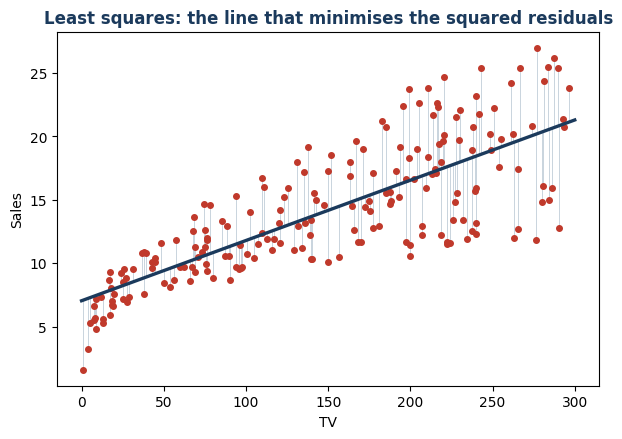

In [7]:
# the deck's least-squares picture: every gray segment is a residual e_i
fig, ax = plt.subplots(figsize=(7, 4.6))
xs = np.linspace(0, 300, 2)
yhat = m1.predict(adv)
for x, y, yh in zip(adv.TV, adv.Sales, yhat):
    ax.plot([x, x], [y, yh], color="#c9d4dd", lw=0.7, zorder=1)
ax.scatter(adv.TV, adv.Sales, s=16, color=ALARM, zorder=2)
ax.plot(xs, m1.params["Intercept"] + m1.params["TV"]*xs, color=NAVY, lw=2.4, zorder=3)
ax.set_xlabel("TV"); ax.set_ylabel("Sales")
ax.set_title("Least squares: the line that minimises the squared residuals",
             color=NAVY, fontweight="bold")
plt.show()

Before any formulas — look at actual rows. `predicted` is the line's
answer; `residual` is the miss the gray segments drew above.

In [8]:
adv.assign(predicted=m1.predict(adv).round(2),
           residual=lambda d: (d.Sales - d.predicted).round(2)).head(6)

,TV,Radio,Newspaper,Sales,predicted,residual
1,230.1,37.8,69.2,22.1,17.97,4.13
2,44.5,39.3,45.1,10.4,9.15,1.25
3,17.2,45.9,69.3,9.3,7.85,1.45
4,151.5,41.3,58.5,18.5,14.23,4.27
5,180.8,10.8,58.4,12.9,15.63,-2.73
6,8.7,48.9,75.0,7.2,7.45,-0.25


### A2. Reading the full summary table *(lab extra — beyond the slides)*
$\hat\beta_1$ came from **one sample**. The standard error, the 95% CI
$\hat\beta_1 \pm 2\cdot\mathrm{SE}(\hat\beta_1)$, and the $t$-test of
$H_0: \beta_1 = 0$ are all in one table — more than the slides showed. Here
$\hat\beta_1 = 0.0475,\ t = 17.67,\ p < 0.0001$ — the TV–sales association is not chance:

In [9]:
tab = pd.DataFrame({"coef": m1.params, "SE": m1.bse,
                    "t": m1.tvalues, "p": m1.pvalues}).round(4)
display(tab)
lo, hi = m1.conf_int().loc["TV"]
print(f"\n95% CI for the TV slope: [{lo:.4f}, {hi:.4f}]  (zero is far outside)")

,coef,SE,t,p
Intercept,7.0326,0.4578,15.3603,0.0
TV,0.0475,0.0027,17.6676,0.0



95% CI for the TV slope: [0.0422, 0.0528]  (zero is far outside)


### A3. Scoring the miss by hand: RMSE, MAE, R² *(slides 12–13 + lab extras)*
The slides only use $R^2$; RMSE and MAE are lab extras that put the miss in
**units of sales** — the "translate the miss" move from slide 13. All three
come straight from the residuals, no library shortcuts.

In [10]:
e = adv.Sales - m1.predict(adv)          # residuals e_i = y_i - yhat_i
rmse = np.sqrt(np.mean(e**2))
mae  = np.mean(np.abs(e))
tss  = np.sum((adv.Sales - adv.Sales.mean())**2)
rss  = np.sum(e**2)
r2   = 1 - rss/tss
print(f"RMSE = {rmse:.2f}   MAE = {mae:.2f}   R^2 = {r2:.2f}")
assert abs(r2 - m1.rsquared) < 1e-12     # matches statsmodels exactly

RMSE = 3.24   MAE = 2.55   R^2 = 0.61

**Is $R^2 = 0.61$ good?** *(slides 12–13)* The deck's honest answer:
**cannot tell** — physics expects 0.99, social science celebrates 0.3.
A number only becomes an answer with context. Keep that in mind for Part B,
where a *far* more dangerous number shows up.

### A4. Two predictors: `Sales ~ TV + Radio` *(slides 10–11)*
Each coefficient is the effect **with the other predictors held fixed** —
that phrase becomes the key to Part B's sign-flip.

,coef
Intercept,2.9211
TV,0.0458
Radio,0.1880



R^2: TV alone 0.61  ->  TV + Radio 0.90


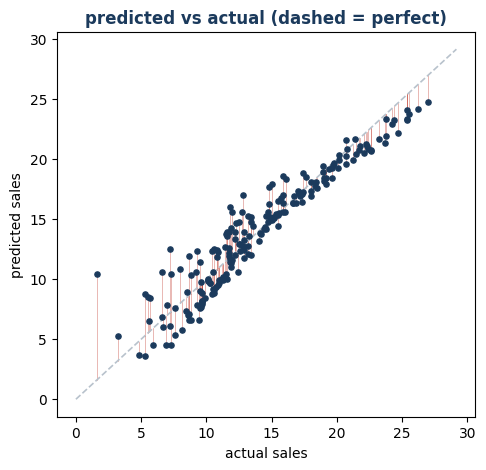

In [11]:
m2 = smf.ols("Sales ~ TV + Radio", data=adv).fit()
display(m2.params.round(4).to_frame("coef"))
print(f"\nR^2: TV alone {m1.rsquared:.2f}  ->  TV + Radio {m2.rsquared:.2f}")

fig, ax = plt.subplots(figsize=(5.4, 5))
lim = [0, adv.Sales.max()*1.08]
ax.plot(lim, lim, "--", color="#b8c2cc", lw=1.2)
yh2 = m2.predict(adv)
for y, yh in zip(adv.Sales, yh2):
    ax.plot([y, y], [y, yh], color=ALARM, lw=0.5, alpha=0.5, zorder=1)
ax.scatter(adv.Sales, yh2, s=14, color=NAVY, zorder=2)
ax.set_xlabel("actual sales"); ax.set_ylabel("predicted sales")
ax.set_title("predicted vs actual (dashed = perfect)", color=NAVY, fontweight="bold")
plt.show()

### A5. Straight lines are not sacred *(slides 15–16)*
`Auto`: mpg vs horsepower is a curve. Fit polynomial degrees 1, 2, 5 and watch
training RMSE — it **always** falls as the fit gets more flexible. Whether the
flexible fit *predicts* better is next week's question (validation).

**Meet the data: `Auto`** *(slide 14)* — 392 cars.
**Inputs (X):** `horsepower`, `weight`, `cylinders`, `displacement`, `year`, `origin`, ...
**Output (Y):** `mpg` (miles per gallon) → a number → still **regression**.

In [12]:
print(f"shape: {Auto.shape[0]} rows x {Auto.shape[1]} columns")
print(f"dtypes: {dict(Auto.dtypes.astype(str))}")
display(Auto.head(4))
display(Auto[["mpg", "horsepower", "weight", "year"]].describe().round(1))

shape: 392 rows x 8 columns
dtypes: {'mpg': 'float64', 'cylinders': 'int64', 'displacement': 'float64', 'horsepower': 'int64', 'weight': 'int64', 'acceleration': 'float64', 'year': 'int64', 'origin': 'int64'}


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1


,mpg,horsepower,weight,year
count,392.0,392.0,392.0,392.0
mean,23.4,104.5,2977.6,76.0
std,7.8,38.5,849.4,3.7
min,9.0,46.0,1613.0,70.0
25%,17.0,75.0,2225.2,73.0
50%,22.8,93.5,2803.5,76.0
75%,29.0,126.0,3614.8,79.0
max,46.6,230.0,5140.0,82.0


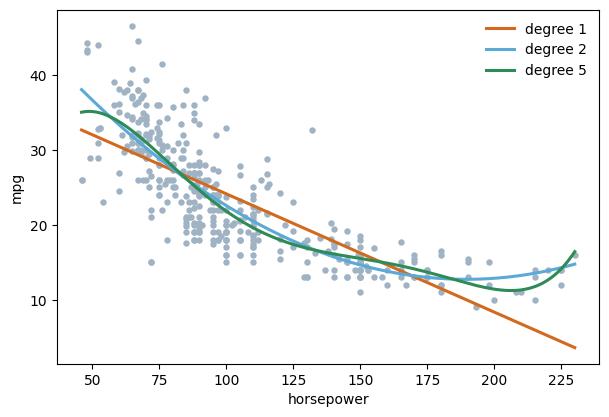

degree : training RMSE   (watch it only go down)
   1   :   4.893
   2   :   4.357
   3   :   4.353
   4   :   4.345
   5   :   4.293
   6   :   4.271
   7   :   4.252
   8   :   4.250


In [13]:
x, y = Auto.horsepower.astype(float), Auto.mpg
fig, ax = plt.subplots(figsize=(7, 4.6))
ax.scatter(x, y, s=13, color="#9fb3c4")
grid = np.linspace(x.min(), x.max(), 200)
for deg, col in [(1, ORANGE), (2, BLUE), (5, "#2e8b57")]:
    c = np.polyfit(x, y, deg)
    ax.plot(grid, np.polyval(c, grid), color=col, lw=2.2, label=f"degree {deg}")
ax.set_xlabel("horsepower"); ax.set_ylabel("mpg"); ax.legend(frameon=False)
plt.show()

print("degree : training RMSE   (watch it only go down)")
for deg in range(1, 9):
    r = y - np.polyval(np.polyfit(x, y, deg), x)
    print(f"   {deg}   :   {np.sqrt(np.mean(r**2)):.3f}")

## Part B — Chapter 4: predict a category (`Default`)

This is the deck's centrepiece — and the code base for **homework #3**
(pick a threshold and defend it).

### B1. Meet `Default` *(slides 21–22)*

**Meet the data: `Default`** *(slide 21)* — 10,000 credit card customers.
**Inputs (X):** `balance` (credit card balance), `income`, `student` (Yes/No).
**Output (Y):** `default` — Yes/No → a **category** → **classification**.
The running example for all of Chapter 4.

In [14]:
print(f"shape: {Default.shape[0]:,} rows x {Default.shape[1]} columns")
print(f"dtypes: {dict(Default.dtypes.astype(str))}")
display(Default.head(4))
display(Default[["balance", "income"]].describe().round(0))
# the two categorical columns: how the 10,000 customers split
display(pd.DataFrame({"default": Default.default.value_counts(),
                      "student": Default.student.value_counts()}))

shape: 10,000 rows x 4 columns
dtypes: {'default': 'category', 'student': 'category', 'balance': 'float64', 'income': 'float64'}


,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935


,balance,income
count,10000.0,10000.0
mean,835.0,33517.0
std,484.0,13337.0
min,0.0,772.0
25%,482.0,21340.0
50%,824.0,34553.0
75%,1166.0,43808.0
max,2654.0,73554.0


,default,student
No,9667,7056
Yes,333,2944


n = 10,000,  defaulters = 333  (3.33%)  <- remember this number


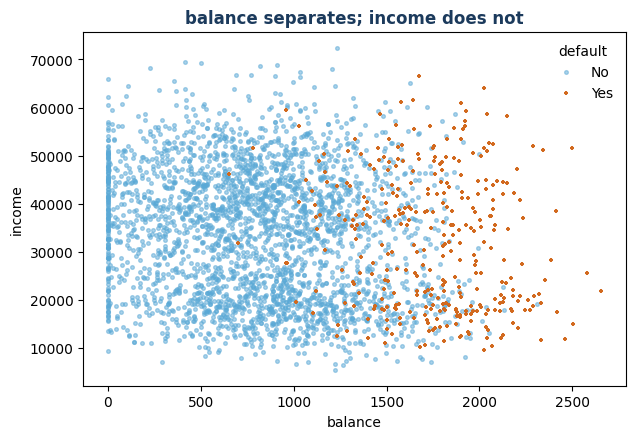

In [15]:
Default["default01"] = (Default.default == "Yes").astype(int)
base_rate = Default.default01.mean()
print(f"n = {len(Default):,},  defaulters = {Default.default01.sum()}  "
      f"({base_rate:.2%})  <- remember this number")

rng = np.random.default_rng(1)
show = Default.sample(3000, random_state=1)
fig, ax = plt.subplots(figsize=(7, 4.6))
no  = show[show.default == "No"]
yes = Default[Default.default == "Yes"]
ax.scatter(no.balance, no.income, s=7, color=BLUE, alpha=0.5, label="No")
ax.scatter(yes.balance, yes.income, s=12, color=ORANGE, marker="+", label="Yes")
ax.set_xlabel("balance"); ax.set_ylabel("income"); ax.legend(frameon=False, title="default")
ax.set_title("balance separates; income does not", color=NAVY, fontweight="bold")
plt.show()

### B2. Why not just run linear regression? *(slide 23)*
Code the response 0/1 and a straight line happily predicts probabilities
below 0 — the S-curve exists to fix exactly this.

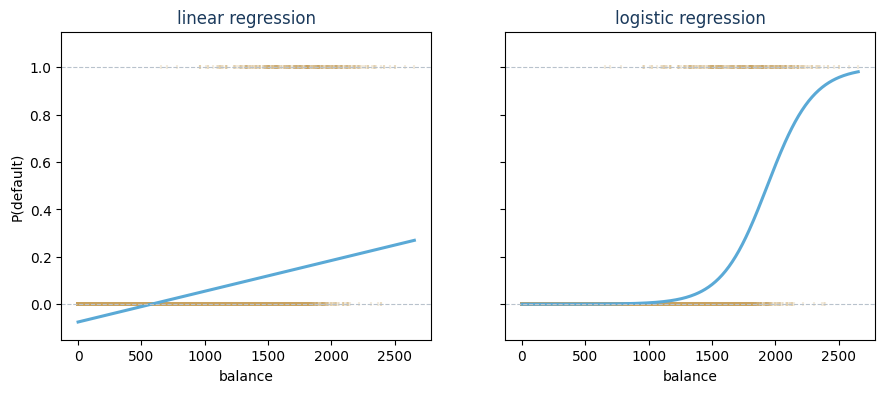

linear model at balance=0: -0.075   <- a negative probability


In [16]:
lin = smf.ols("default01 ~ balance", data=Default).fit()
log = smf.glm("default01 ~ balance", data=Default,
              family=sm.families.Binomial()).fit()
grid = pd.DataFrame({"balance": np.linspace(0, Default.balance.max(), 300)})

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4), sharey=True)
for ax, model, title in [(axes[0], lin, "linear regression"),
                         (axes[1], log, "logistic regression")]:
    ax.scatter(Default.balance, Default.default01, s=5, color="#c9a25e",
               alpha=0.2, marker="|")
    ax.plot(grid.balance, model.predict(grid), color=BLUE, lw=2.2)
    ax.axhline(0, ls="--", color="#b8c2cc", lw=0.8)
    ax.axhline(1, ls="--", color="#b8c2cc", lw=0.8)
    ax.set_xlabel("balance"); ax.set_title(title, color=NAVY)
axes[0].set_ylabel("P(default)"); axes[0].set_ylim(-0.15, 1.15)
plt.show()
print(f"linear model at balance=0: {lin.predict(pd.DataFrame({'balance':[0]}))[0]:+.3f}"
      "   <- a negative probability")

### B3. Fitting and using the logistic model *(slides 24–25)*
Slide 25 shows fitting as walking downhill on the **deviance** surface — here
is the bottom of that bowl:
The deck quoted $\hat\beta_0=-10.65$, $\hat\beta_1=0.0055$, $z=24.9$, and the
two predictions 0.6% at \$1,000 vs 58.6% at \$2,000. Verify all four:

In [17]:
display(pd.DataFrame({"coef": log.params, "z": log.tvalues}).round(4))
for bal in [1000, 2000]:
    p = log.predict(pd.DataFrame({"balance": [bal]}))[0]
    print(f"balance = ${bal:,}  ->  p(default) = {p:.1%}")
print("\n$2,000 is not twice as risky as $1,000 — it is ~100x. "
      "That is the S-curve doing its job.")

,coef,z
Intercept,-10.6513,-29.4913
balance,0.0055,24.9524


balance = $1,000  ->  p(default) = 0.6%
balance = $2,000  ->  p(default) = 58.6%

$2,000 is not twice as risky as $1,000 — it is ~100x. That is the S-curve doing its job.


### B4. The confusion matrix and the accuracy trap *(slides 26–29)*
Fit the full model (`balance + income + student`), classify at the usual 0.5,
and admire the accuracy — then look at what it does to actual defaulters.

In [18]:
full = smf.glm("default01 ~ balance + income + student", data=Default,
               family=sm.families.Binomial()).fit()
p_hat = full.predict(Default)

def confusion(threshold):
    pred = (p_hat >= threshold).astype(int)
    tn = int(((pred == 0) & (Default.default01 == 0)).sum())
    fp = int(((pred == 1) & (Default.default01 == 0)).sum())
    fn = int(((pred == 0) & (Default.default01 == 1)).sum())
    tp = int(((pred == 1) & (Default.default01 == 1)).sum())
    return tn, fp, fn, tp

tn, fp, fn, tp = confusion(0.5)
n = len(Default)
display(pd.DataFrame([[tn, fp], [fn, tp]],
                    index=["truth: no", "truth: default"],
                    columns=["pred: no", "pred: default"]))
acc    = (tn + tp) / n
missed = fn / (fn + tp)
print(f"\naccuracy         = {acc:.2%}   <- the deck's 'congratulations' number")
print(f"null model       = {1-base_rate:.2%}   (just answer 'nobody defaults')")
print(f"defaulters missed = {missed:.1%}   <- more than 2 of every 3")
prec, rec = tp/(tp+fp), tp/(tp+fn)
print(f"precision = {prec:.1%}   recall = {rec:.1%}   "
      f"F1 = {2*prec*rec/(prec+rec):.3f}")

,pred: no,pred: default
truth: no,9627,40
truth: default,228,105



accuracy         = 97.32%   <- the deck's 'congratulations' number
null model       = 96.67%   (just answer 'nobody defaults')
defaulters missed = 68.5%   <- more than 2 of every 3
precision = 72.4%   recall = 31.5%   F1 = 0.439


Now look at **actual defaulters** and what the model said about them.
Watch the `p_hat` column: most sit *below* 0.5 — that is the 68.5% in one table.

In [19]:
peek = Default[["default", "student", "balance", "income"]].assign(
    p_hat=p_hat.round(3))
below = (p_hat[Default.default01 == 1] < 0.5).sum()
print(f"actual defaulters with p_hat < 0.5: {below} of {Default.default01.sum()}\n")
peek[peek.default == "Yes"].head(6)

actual defaulters with p_hat < 0.5: 228 of 333



,default,student,balance,income,p_hat
136,Yes,Yes,1486.998122,17854.397028,0.051
173,Yes,Yes,2205.799521,14271.492253,0.765
201,Yes,Yes,1774.694223,20359.506086,0.219
206,Yes,No,1889.599190,48956.171589,0.530
209,Yes,Yes,1899.390626,20655.200003,0.364
241,Yes,Yes,1572.856481,14930.178331,0.080


**Exercise — the quiz from slide 28.** A model screened 100 loan
applications: TN 50, FP 10, FN 15, TP 25. Compute Accuracy, Precision, Recall,
and F1 **by hand first**, then check yourself below. (Answers are not on the
slide — or here.)

In [20]:
tn, fp, fn, tp = 50, 10, 15, 25
# your check here — e.g.  print((tp + tn) / (tn + fp + fn + tp))


### B5. So move the threshold yourself *(slides 29–30, and homework #3)*
The two numbers fight: push the threshold down to catch more defaulters and
the overall error rises. **Neither statistics nor the model can tell you where
to stop — that is a business decision.**

First the whole battlefield, then a cell where you pick your spot on it.

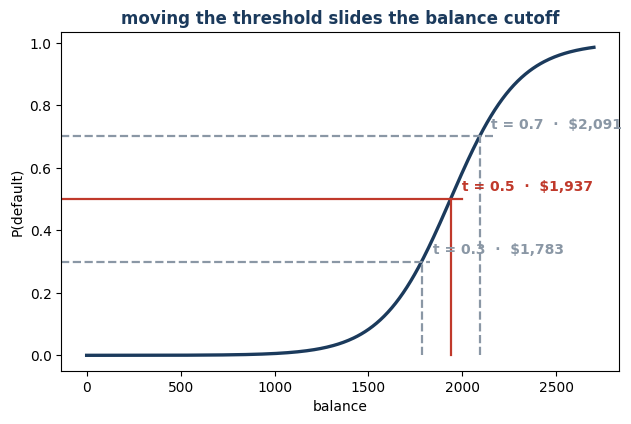

cutoffs: {0.3: '$1,783', 0.5: '$1,937', 0.7: '$2,091'}


In [21]:
# slide 29's picture: the threshold is a horizontal line on the S-curve
b0, b1 = log.params["Intercept"], log.params["balance"]
cut = lambda t: (np.log(t / (1 - t)) - b0) / b1
grid2 = np.linspace(0, 2700, 400)
fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.plot(grid2, 1/(1+np.exp(-(b0 + b1*grid2))), color=NAVY, lw=2.4)
for t, col, ls in [(0.3, GRAY, "--"), (0.5, ALARM, "-"), (0.7, GRAY, "--")]:
    c = cut(t)
    ax.axhline(t, xmax=c/2700, color=col, ls=ls, lw=1.6)
    ax.plot([c, c], [0, t], color=col, ls=ls, lw=1.6)
    ax.annotate(f"t = {t}  ·  ${c:,.0f}", (c, t), textcoords="offset points",
                xytext=(8, 6), fontsize=10, color=col, fontweight="bold")
ax.set_xlabel("balance"); ax.set_ylabel("P(default)")
ax.set_title("moving the threshold slides the balance cutoff",
             color=NAVY, fontweight="bold")
plt.show()
print("cutoffs:", {t: f"${cut(t):,.0f}" for t in (0.3, 0.5, 0.7)})

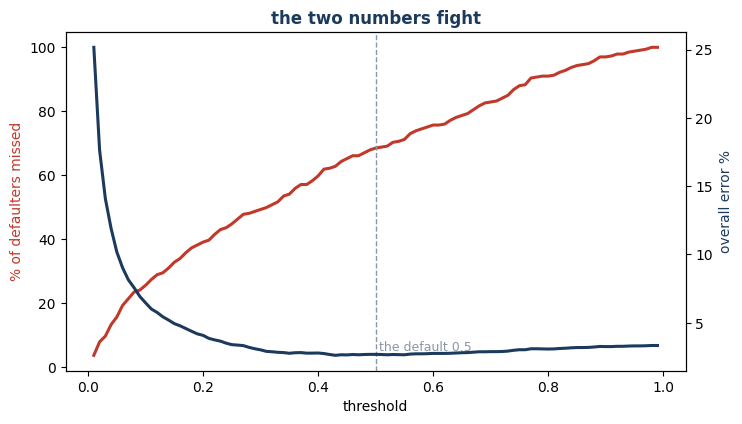

In [22]:
ths = np.arange(0.01, 1.00, 0.01)
rows = [confusion(t) for t in ths]
missed_pct = [fn/(fn+tp)*100 for tn, fp, fn, tp in rows]
err_pct    = [(fp+fn)/n*100  for tn, fp, fn, tp in rows]

fig, ax1 = plt.subplots(figsize=(8, 4.4))
ax1.plot(ths, missed_pct, color=ALARM, lw=2.2, label="% of defaulters missed")
ax1.set_ylabel("% of defaulters missed", color=ALARM)
ax2 = ax1.twinx()
ax2.plot(ths, err_pct, color=NAVY, lw=2.2, label="overall error %")
ax2.set_ylabel("overall error %", color=NAVY)
ax1.axvline(0.5, ls="--", color=GRAY, lw=1)
ax1.text(0.505, 5, "the default 0.5", color=GRAY, fontsize=9)
ax1.set_xlabel("threshold")
ax1.set_title("the two numbers fight", color=NAVY, fontweight="bold")
plt.show()

In [23]:
# ============ HOMEWORK #3 STARTS HERE ============
# Change THRESHOLD, rerun, repeat until you can defend your choice
# in one paragraph. There is no right answer.
THRESHOLD = 0.20     # the slides walked through 0.3, 0.5, 0.7 — try those too

tn, fp, fn, tp = confusion(THRESHOLD)
display(pd.DataFrame([[tn, fp], [fn, tp]],
                    index=["truth: no", "truth: default"],
                    columns=["pred: no", "pred: default"]))
print(f"\nthreshold          = {THRESHOLD:.2f}")
print(f"defaulters missed  = {fn/(fn+tp):.1%}")
print(f"overall error      = {(fp+fn)/n:.2%}")
print(f"customers flagged  = {fp+tp:,}  "
      f"(of whom {fp:,} are good customers you just annoyed)")

,pred: no,pred: default
truth: no,9390,277
truth: default,130,203



threshold          = 0.20
defaulters missed  = 39.0%
overall error      = 4.07%
customers flagged  = 480  (of whom 277 are good customers you just annoyed)


### B6. The ROC curve: all thresholds at once *(slides 31, 33–34)*

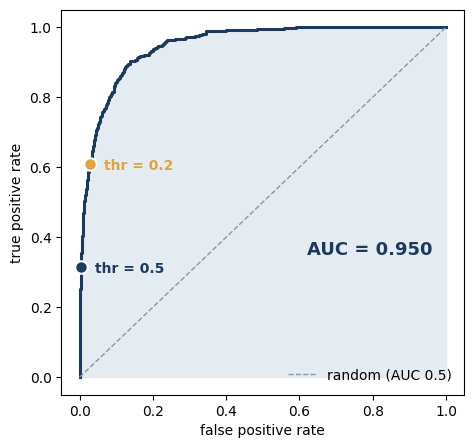

AUC = 0.950


In [24]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(Default.default01, p_hat)
A = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(5.2, 5))
ax.fill_between(fpr, tpr, color="#dbe4ec", alpha=0.7)
ax.plot(fpr, tpr, color=NAVY, lw=2.2)
ax.plot([0, 1], [0, 1], ls="--", color=GRAY, lw=1, label="random (AUC 0.5)")
for t, col in [(0.5, NAVY), (0.2, AMBER)]:
    tn, fp, fn, tp = confusion(t)
    ax.plot(fp/(fp+tn), tp/(tp+fn), "o", ms=9, color=col,
            mec="white", mew=1.5)
    ax.annotate(f"thr = {t}", (fp/(fp+tn), tp/(tp+fn)),
                textcoords="offset points", xytext=(10, -4), color=col,
                fontweight="bold")
ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate")
ax.text(0.62, 0.35, f"AUC = {A:.3f}", fontsize=13, color=NAVY, fontweight="bold")
ax.legend(frameon=False, loc="lower right")
plt.show()
print(f"AUC = {A:.3f}")

### B7. Optional extra: a coefficient can flip sign
*(not covered on this week's slides — skip freely)*

Fit `student` alone, then add `balance`, and watch the sign reverse — because
a coefficient measures the effect *with the other predictors held fixed*
(remember A4?).

student coefficient, alone                    : +0.405
student coefficient, with balance and income  : -0.647


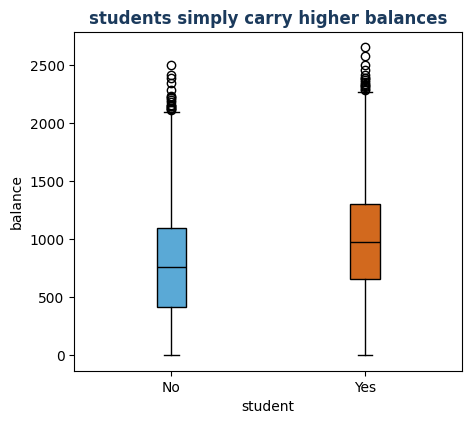


Balance was doing the work; student was taking the credit.


In [25]:
alone = smf.glm("default01 ~ student", data=Default,
                family=sm.families.Binomial()).fit()
# 'full' is the balance + income + student model fitted in B4
print(f"student coefficient, alone                    : {alone.params['student[T.Yes]']:+.3f}")
print(f"student coefficient, with balance and income  : {full.params['student[T.Yes]']:+.3f}")

fig, ax = plt.subplots(figsize=(5, 4.4))
data = [Default.balance[Default.student == "No"],
        Default.balance[Default.student == "Yes"]]
bp = ax.boxplot(data, tick_labels=["No", "Yes"], patch_artist=True,
                medianprops=dict(color="black"))
for patch, c in zip(bp["boxes"], [BLUE, ORANGE]):
    patch.set_facecolor(c)
ax.set_xlabel("student"); ax.set_ylabel("balance")
ax.set_title("students simply carry higher balances", color=NAVY, fontweight="bold")
plt.show()
print("\nBalance was doing the work; student was taking the credit.")

## Part C — bridge to the official Ch. 4 lab (`Smarket`) *(slide 35)*

Run the deck's snippet on the stock market and get the most useful result in
the lab: **barely a coin flip**. A model that reports honestly that it knows
nothing has told you something true.

**Meet the data: `Smarket`** *(slide 2, row four)* — 1,250 trading days
of the S&P 500, 2001–2005.
**Inputs (X):** `Lag1`–`Lag5` (previous five days' returns, %), `Volume`.
**Output (Y):** `Direction` — the market went Up/Down → a **category** →
**classification**.

In [26]:
print(f"shape: {Smarket.shape[0]:,} rows x {Smarket.shape[1]} columns")
print(f"dtypes: {dict(Smarket.dtypes.astype(str))}")
display(Smarket[["Year", "Lag1", "Lag2", "Lag3", "Volume", "Today",
                 "Direction"]].head(4))
display(Smarket[["Lag1", "Lag2", "Volume", "Today"]].describe().round(3))
display(Smarket.Direction.value_counts().to_frame("days"))

shape: 1,250 rows x 9 columns
dtypes: {'Year': 'int64', 'Lag1': 'float64', 'Lag2': 'float64', 'Lag3': 'float64', 'Lag4': 'float64', 'Lag5': 'float64', 'Volume': 'float64', 'Today': 'float64', 'Direction': 'category'}


,Year,Lag1,Lag2,Lag3,Volume,Today,Direction
0,2001,0.381,-0.192,-2.624,1.1913,0.959,Up
1,2001,0.959,0.381,-0.192,1.2965,1.032,Up
2,2001,1.032,0.959,0.381,1.4112,-0.623,Down
3,2001,-0.623,1.032,0.959,1.2760,0.614,Up


,Lag1,Lag2,Volume,Today
count,1250.000,1250.000,1250.000,1250.000
mean,0.004,0.004,1.478,0.003
std,1.136,1.136,0.360,1.136
min,-4.922,-4.922,0.356,-4.922
25%,-0.640,-0.640,1.257,-0.640
50%,0.039,0.039,1.423,0.038
75%,0.597,0.597,1.642,0.597
max,5.733,5.733,3.152,5.733


,days
Direction,
Up,648
Down,602


In [27]:
Smarket["up"] = (Smarket.Direction == "Up").astype(int)
mkt = smf.glm("up ~ Lag1 + Lag2 + Lag3 + Lag4 + Lag5 + Volume",
              data=Smarket, family=sm.families.Binomial()).fit()
display(pd.DataFrame({"coef": mkt.params, "p": mkt.pvalues}).round(3))
print("\nNot a single p-value below 0.05.")

,coef,p
Intercept,-0.126,0.601
Lag1,-0.073,0.145
Lag2,-0.042,0.398
Lag3,0.011,0.824
Lag4,0.009,0.851
Lag5,0.010,0.835
Volume,0.135,0.392



Not a single p-value below 0.05.


In [28]:
# honest evaluation: train on <2005, test on 2005 (as in the official lab)
train = Smarket.Year < 2005
mkt_tr = smf.glm("up ~ Lag1 + Lag2 + Lag3 + Lag4 + Lag5 + Volume",
                 data=Smarket[train], family=sm.families.Binomial()).fit()
p_test = mkt_tr.predict(Smarket[~train])
pred   = (p_test >= 0.5).astype(int)
acc    = (pred == Smarket.up[~train]).mean()
print(f"test-year (2005) accuracy: {acc:.1%}   <- worse than a coin flip")
print("\nThat is not a bug in your code — markets are hard.")

test-year (2005) accuracy: 48.0%   <- worse than a coin flip

That is not a bug in your code — markets are hard.


**Continue in the official labs (homework #2):**
- [Ch. 3 lab](https://github.com/intro-stat-learning/ISLP_labs/blob/main/Ch03-linreg-lab.ipynb) —
  interactions (`lstat:age`), polynomial transforms, qualitative predictors on `Carseats` (§3.6.7)
- [Ch. 4 lab](https://github.com/intro-stat-learning/ISLP_labs/blob/main/Ch04-classification-lab.ipynb) —
  LDA, QDA, naive Bayes, KNN on the same `Smarket` data (optional extras).
  The lab's final sections (`Caravan` KNN, `Bikeshare` Poisson) go beyond this week — feel free to skip.

**Homework #3 lives in cell B5 above.** Pick your threshold, print your matrix,
write your paragraph. There is no right answer, and I will push back on
whatever you choose.